In [257]:
from langchain_ollama import OllamaLLM
from langgraph.graph import START, StateGraph, MessagesState
from langchain_core.messages import HumanMessage, AIMessage, RemoveMessage
from typing import Literal

In [258]:
chat = OllamaLLM(
    model="llama3.1:8b",
    temperature=0.5,
    num_predict=100
)

In [259]:
def ask_question(state: MessagesState) -> MessagesState:
    print("Длина цепи запросов для бота = " + len(state["messages"]).__str__())
    question = "Какой вопрос?"
    state["messages"].extend([
        AIMessage(question),
        HumanMessage(input(question))
    ])
    return state

In [260]:
def trim_messages(state: MessagesState) -> MessagesState:
    print("Начали сокращение цепи сообщений. Длина цепи запросов до обрезания = " + len(state["messages"]).__str__())
    if len(state["messages"]) > 3:
        state["messages"] = state["messages"][-3:]
        print(f"Длина цепи запросов после обрезания = " + len(state["messages"]).__str__())
    return state

In [261]:
def chatbot(state: MessagesState) -> MessagesState:
    print("Длина цепи запросов для бота = " + len(state["messages"]).__str__())
    response = chat.invoke(state["messages"])
    print("Ответ: " + response)
    return MessagesState(messages = [response])

In [262]:
def ask_another_question(state: MessagesState) -> MessagesState:
    question = "Есть еще вопросы (да/нет)?"
    return MessagesState(messages = [AIMessage(question), HumanMessage(input(question))])

In [263]:
def routing_function(state: MessagesState) -> Literal["trim_messages", "__end__"]:
    
    if state["messages"][-1].content == "да":
        return "trim_messages"
    else:
        return "__end__"

### Define the Graph

In [264]:
graph = StateGraph(MessagesState)

In [265]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_edge("trim_messages", "ask_question")
graph.add_conditional_edges(source = "ask_another_question",
                            path = routing_function)

In [265]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)
graph.add_node("trim_messages", trim_messages)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_edge("trim_messages", "ask_question")
graph.add_conditional_edges(source = "ask_another_question",
                            path = routing_function)

In [266]:
graph_compiled = graph.compile()

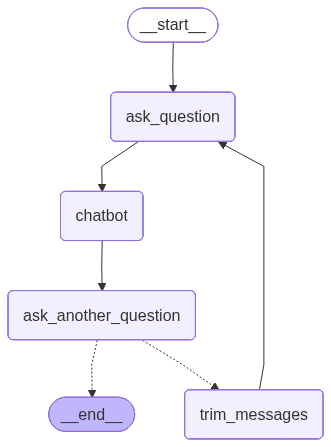

In [267]:
graph_compiled

### Test the Graph

In [268]:
graph_compiled.invoke(MessagesState(messages = []))

Длина цепи запросов для бота = 0


KeyboardInterrupt: Interrupted by user